# Урок 2.1. Решающий пень: одно лучшее разбиение

**Интерактивная версия:** `lessons/lesson_2_1/web/index.html`

1. Наивный перебор порогов: $O(n^2)$.
2. Один проход с накопленными суммами: $O(n)$ после сортировки.
3. Формула выигрыша и проверка против scikit-learn.
4. Несколько признаков.

In [1]:
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from gbcourse import datasets, RegressionTree
from gbcourse.plotting import use_course_style, plot_data

use_course_style()

## 1. Наивный перебор на шести точках

In [2]:
X, y = datasets.toy_regression()
x = X[:, 0]


def sse_split(x, y, t):
    left = x <= t
    return ((y[left] - y[left].mean()) ** 2).sum() + ((y[~left] - y[~left].mean()) ** 2).sum()


rows = []
xs = np.sort(np.unique(x))
for a, b in zip(xs[:-1], xs[1:]):
    t = (a + b) / 2
    left = x <= t
    rows.append({"порог": t, "n_L": left.sum(), "ȳ_L": y[left].mean(), "ȳ_R": y[~left].mean(), "SSE": sse_split(x, y, t)})
table = pd.DataFrame(rows)
table["выигрыш Δ"] = ((y - y.mean()) ** 2).sum() - table["SSE"]
table

,порог,n_L,ȳ_L,ȳ_R,SSE,выигрыш Δ
0,1.5,1,2.0,6.8,44.8,19.2
1,2.5,2,3.0,7.5,37.0,27.0
2,3.5,3,3.0,9.0,10.0,54.0
3,4.5,4,4.0,10.0,16.0,48.0
4,5.5,5,5.0,11.0,34.0,30.0


Лучший порог 3.5: слева среднее 3, справа 9, SSE падает с 64 до 10, выигрыш 54.

## 2. Один проход с накопленными суммами

In [3]:
def best_split_fast(x, y):
    order = np.argsort(x, kind="stable")
    xs, ys = x[order], y[order]
    n, S = len(ys), ys.sum()
    SL = np.cumsum(ys)[:-1]
    nL = np.arange(1, n)
    gain = SL**2 / nL + (S - SL) ** 2 / (n - nL) - S**2 / n
    gain[xs[:-1] == xs[1:]] = -np.inf
    k = int(np.argmax(gain))
    return (xs[k] + xs[k + 1]) / 2, gain[k]


def best_split_naive(x, y):
    xs = np.unique(x)
    best = (None, np.inf)
    for a, b in zip(xs[:-1], xs[1:]):
        t = (a + b) / 2
        s = sse_split(x, y, t)
        if s < best[1]:
            best = (t, s)
    return best


print("быстрый:", best_split_fast(x, y), " наивный:", best_split_naive(x, y))

быстрый: (np.float64(3.5), np.float64(54.0))  наивный: (np.float64(3.5), np.float64(10.0))


Сравним скорость на больших данных:

In [4]:
for n in (500, 2000, 8000):
    Xb, yb = datasets.regression_1d("wave", n=n, noise=0.5, seed=1)
    t0 = time.perf_counter()
    tf, _ = best_split_fast(Xb[:, 0], yb)
    t1 = time.perf_counter()
    tn, _ = best_split_naive(Xb[:, 0], yb)
    t2 = time.perf_counter()
    print(f"n = {n:5d}: быстрый {1e3 * (t1 - t0):7.2f} мс, наивный {1e3 * (t2 - t1):8.1f} мс, пороги совпали: {np.isclose(tf, tn)}")

n =   500: быстрый    0.08 мс, наивный      4.2 мс, пороги совпали: True
n =  2000: быстрый    0.12 мс, наивный     23.1 мс, пороги совпали: True


n =  8000: быстрый    0.30 мс, наивный    176.2 мс, пороги совпали: True


## 3. Формула выигрыша и сверка с scikit-learn

$\Delta = \frac{n_L n_R}{n}(\bar y_L - \bar y_R)^2$. Проверим на данных со ступенькой.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Δ по накопленным суммам: 21.597865
Δ по формуле:           21.597865
порог sklearn: 3.051472, наш: 3.051472


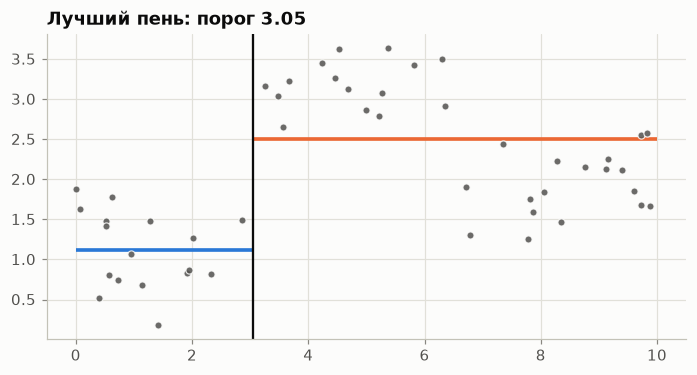

In [5]:
Xs, ys = datasets.regression_1d("step", n=50, noise=0.4, seed=2)
t, gain = best_split_fast(Xs[:, 0], ys)
left = Xs[:, 0] <= t
nL, nR = left.sum(), (~left).sum()
print(f"Δ по накопленным суммам: {gain:.6f}")
print(f"Δ по формуле:           {nL * nR / len(ys) * (ys[left].mean() - ys[~left].mean()) ** 2:.6f}")
sk = DecisionTreeRegressor(max_depth=1).fit(Xs, ys)
print(f"порог sklearn: {sk.tree_.threshold[0]:.6f}, наш: {t:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
plot_data(ax, Xs, ys)
ax.hlines([ys[left].mean(), ys[~left].mean()], [0, t], [t, 10], colors=["#2a78d6", "#eb6834"], lw=2.4)
ax.axvline(t, color="#0b0b0b", lw=1.5)
ax.set_title(f"Лучший пень: порог {t:.2f}")
plt.show()

## 4. Несколько признаков

Для каждого признака — лучший порог; из них — лучший по выигрышу.

In [6]:
Xf, yf = datasets.friedman1(n=400, noise=1.0, seed=3, n_features=6)
gains = [best_split_fast(Xf[:, j], yf) for j in range(Xf.shape[1])]
for j, (t, g) in enumerate(gains):
    print(f"x{j}: порог {t:.3f}, выигрыш {g:8.1f}")
jbest = int(np.argmax([g for _, g in gains]))
stump = RegressionTree(max_depth=1).fit(Xf, -yf)
print(f"лучший признак: x{jbest}; gbcourse выбрал x{stump.nodes[0].feature}, порог {stump.nodes[0].threshold:.3f}")

x0: порог 0.303, выигрыш   1317.9
x1: порог 0.308, выигрыш   1305.8
x2: порог 0.830, выигрыш    302.7
x3: порог 0.410, выигрыш   2927.3
x4: порог 0.341, выигрыш    540.8
x5: порог 0.028, выигрыш     82.7
лучший признак: x3; gbcourse выбрал x3, порог 0.410


## Упражнения

1. Докажите тождество $\frac{S_L^2}{n_L} + \frac{S_R^2}{n_R} - \frac{S^2}{n} = \frac{n_L n_R}{n}(\bar y_L - \bar y_R)^2$ (подсказка: $S = S_L + S_R$).
2. Добавьте в `best_split_fast` ограничение «в каждой части не меньше `min_leaf` объектов».
3. Как изменится лучший порог на шести точках, если последнее значение y = 11 заменить на 30?

Решения: `python lessons/lesson_2_1/exercises/solutions.py`.